# 🏥 Heart Failure Risk Prediction  

---

## 🧐 Context  

**Heart failure** is a severe chronic condition that impairs the heart’s ability to pump blood effectively. It can lead to life-threatening complications if not detected early.  

With the advancement of **medical data analysis** and **artificial intelligence**, we can now develop predictive models to assess heart failure risk and assist doctors in making more informed decisions.  

---

## 🎯 Project Objectives  

📌 **Our goal?** Develop a **Machine Learning model** capable of **predicting the risk of death** due to heart failure based on clinical data.  

📌 **Why?**  
🔹 Improve **patient care** and early risk detection.  
🔹 Identify the **most influential medical factors**.  
🔹 Provide a **clear explanation** of model predictions using **SHAP**.  
🔹 Design an **intuitive interface** for seamless clinical use.  



--
--

---

## 📊 Dataset Source  

📂 **Dataset Name**: *Heart Failure Clinical Records*  
📍 **Source**: UCI Machine Learning Repository  
🔗 **Link**: [UCI Heart Failure Dataset](https://archive.ics.uci.edu/dataset/519/heart%2Bfailure%2Bclinical%2Brecords)  

> 💡 This dataset contains **clinical data** on patients with heart failure, including biological measurements, medical history, and follow-up information. It serves as the foundation for training and testing our predictive models.  

---





## 🤖 Machine Learning Methodology  

📌 **1. Data Collection & Preprocessing**  
✔️ Load the dataset and explore its structure.  
✔️ Handle missing values and detect outliers.  
✔️ Optimize memory usage to improve performance.  
✔️ Perform feature selection and engineering if necessary.  

📌 **2. Handling Class Imbalance**  
✔️ Analyze the dataset distribution (68% survived, 32% deceased).  
✔️ Apply class balancing techniques such as **SMOTE, undersampling, or class-weighting**.  

📌 **3. Model Selection & Training**  
✔️ Choose at least three models for evaluation:  
   - Random Forest  
   - XGBoost  
   - LightGBM  
   - Logistic Regression  
✔️ Split the dataset into **training** and **test** sets.  
✔️ Train models using **cross-validation** for robustness.  

📌 **4. Model Evaluation**  
✔️ Assess performance using the following metrics:  
   - **ROC-AUC Score**  
   - **Accuracy**  
   - **Precision, Recall & F1-score**  
✔️ Compare model results and select the best-performing one.  

📌 **5. Model Explainability with SHAP**  
✔️ Implement **SHAP (SHapley Additive exPlanations)** to interpret model predictions.  
✔️ Generate **SHAP summary plots** to visualize feature importance.  

📌 **6. Deployment & User Interface**  
✔️ Develop an interactive **Flask** web application for real-time predictions.  
✔️ Allow physicians to input patient data and visualize results.  

---


****REQUIREMENTS INSTALLATION****

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pickle

# 1. Read Dataset

In [ ]:
# Chargement du fichier
data = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [ ]:
#Taille des données
data.shape

total = data.shape[0]
print("total of pacients %s"%(total))
print(f"The dataset has {data.shape[1]} features from {data.shape[0]} patients")

total of pacients 299
The dataset has 13 features from 299 patients


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [ ]:
data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


---

## 📌 **DATASET UNDERSTANDING**

| Nom de la colonne              | Description claire                                       | Type            | Unité                | Remarque                             |
|--------------------------------|----------------------------------------------------------|-----------------|----------------------|--------------------------------------|
| **anaemia**                    | Diminution des globules rouges ou de l'hémoglobine       | Booléen         | 0 (Non), 1 (Oui)    | Indicateur médical (anémie)          |
| **creatinine_phosphokinase**   | Niveau de l'enzyme CPK dans le sang                      | Quantitatif     | mcg/L                | Marqueur de lésion musculaire        |
| **diabetes**                   | Présence ou absence du diabète                           | Booléen         | 0 (Non), 1 (Oui)     | Facteur de risque cardiovasculaire   |
| **ejection_fraction**          | Fraction de sang éjectée du ventricule gauche            | Quantitatif     | Pourcentage (%)      | Indicateur clé de la fonction cardiaque |
| **high_blood_pressure**        | Hypertension artérielle                                  | Booléen         | 0=Non, 1=Oui         | Facteur de risque cardiovasculaire   |
| **platelets**                  | Nombre de plaquettes sanguines                           | Quantitatif     | kiloplaquettes/mL    | Important pour la coagulation        |
| **serum_creatinine**           | Concentration de créatinine sérique                      | Quantitatif     | mg/dL                | Indicateur de la fonction rénale     |
| **serum_sodium**               | Concentration de sodium dans le sang                     | Quantitatif     | mEq/L                | Régulateur nerveux et musculaire     |
| **sex**                        | Genre du patient                                         | Booléen         | 0=Femme, 1=Homme     | Caractéristique démographique        |
| **smoking**                    | Antécédent ou tabagisme actif                            | Booléen         | 0=Non, 1=Oui         | Facteur de risque cardiovasculaire   |
| **time**                       | Durée de suivi du patient                                | Quantitatif     | Jours                 | Durée de suivi du patient            |
| **DEATH_EVENT** (cible)        | Décès dû à une insuffisance cardiaque                    | Booléen         | 0=Survie, 1=Décès    | Variable cible à prédire             |

---

In [ ]:
# Informations sur les types de données
print("Informations sur les types de données : \n")
data.info()

Informations sur les types de données : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10

In [ ]:
import numpy as np
import pandas as pd

# Définition des colonnes par type, d'après ta description
BOOL_COLS = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking", "DEATH_EVENT"]
INT_COLS = ["time"]  # Nombre de jours
FLOAT_COLS = ["creatinine_phosphokinase", "ejection_fraction", "platelets",
              "serum_creatinine", "serum_sodium"]


def optimize_memory(df: pd.DataFrame) -> pd.DataFrame:
    """
    Optimise la mémoire occupée par le DataFrame en ajustant les types de colonnes
    selon leur usage prévu (bool, int16, float16, etc.).

    Paramètres
    ----------
    df : pd.DataFrame
        DataFrame à optimiser. Les modifications se font in-place (retourne df).

    Retour
    ------
    pd.DataFrame
        Le DataFrame optimisé.
    """
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage BEFORE optimization: {start_mem:.2f} MB")

    # Conversion des booléens
    for col in BOOL_COLS:
        if col in df.columns:
            # S'assurer qu'on n'a que 0/1, ou True/False
            # On peut convertir directement si c'est déjà booléen ou 0/1
            df[col] = df[col].astype(bool)

    # Conversion des colonnes entières
    for col in INT_COLS:
        if col in df.columns:
            # Vérifier la plage de valeurs pour choisir int16 ou int32
            col_min, col_max = df[col].min(), df[col].max()
            if col_min >= np.iinfo(np.int16).min and col_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            else:
                df[col] = df[col].astype(np.int32)

    # Conversion des colonnes flottantes
    for col in FLOAT_COLS:
        if col in df.columns:
            # On peut tenter float16, sinon on monte en float32
            col_min, col_max = df[col].min(), df[col].max()
            if col_min > np.finfo(np.float16).min and col_max < np.finfo(np.float16).max:
                df[col] = df[col].astype(np.float16)
            else:
                df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage AFTER optimization:  {end_mem:.2f} MB")
    print(f"Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%")

    return df


# Imaginons que tu aies chargé ton DataFrame :
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

print("=== Mémoire avant ===")
df.info(memory_usage="deep")

# Appliquer la fonction
df_optimized = optimize_memory(df)

print("\n=== Mémoire après ===")
df_optimized.info(memory_usage="deep")


=== Mémoire avant ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5

##**OPTIMIZING MEMORY USAGE**

Elle s’appuie sur la nature de chaque colonne (booléen, entier, flottant) en se basant sur tes spécifications :

    anaemia, diabetes, high_blood_pressure, sex, smoking, DEATH_EVENT : booléens → cast en bool.
    time : entier (jours) → cast en int16 ou int32.
    creatinine_phosphokinase, ejection_fraction, platelets, serum_creatinine, serum_sodium : floats → cast en float16 ou float32.

In [ ]:

def optimize_memory(df: pd.DataFrame) -> pd.DataFrame:
    """
    Réduit la taille en mémoire d'un DataFrame en convertissant
    les types int64/float64 vers des types plus légers (int8/16/32, float16/32).
    """
    start_mem = df.memory_usage().sum() / 1024**2

    print("="*50)
    print("      MEMORY OPTIMIZATION: BEFORE      ")
    print("="*50)
    print(f"DataFrame shape: {df.shape}")
    print(f"Memory usage: {start_mem:.2f} MB\n")

    for col in df.columns:
        col_type = df[col].dtype

        if pd.api.types.is_numeric_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()

            if "int" in str(col_type):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    reduction = 100 * (start_mem - end_mem) / start_mem

    print("\n" + "="*50)
    print("      MEMORY OPTIMIZATION: AFTER       ")
    print("="*50)
    print(f"DataFrame shape: {df.shape}")
    print(f"Memory usage: {end_mem:.2f} MB")

    # Séquence d'échappement ANSI pour du gras et taille plus large (si terminal le gère)
    print("\033[1m\033[94m")  # gras et bleu (94)
    print(f"REDUCED BY: {reduction:.1f}%")
    print("\033[0m")  # reset du style

    print("="*50 + "\n")

    return df


###**DEMO OPTIMIZING MEMORY USAGE**

In [ ]:
# Exemple : on charge un DataFrame
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

# Mémoire avant
print("=== Avant optimisation ===")
df.info(memory_usage="deep")

# Appel de la fonction
df_optimized = optimize_memory(df)

# Mémoire après
print("\n=== Après optimisation ===")
df_optimized.info(memory_usage="deep")


=== Avant optimisation ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage:

# Preprocessing


### **Missing Value**

In [ ]:
# Valeurs manquantes
print("\nValeurs manquantes dans le dataset :\n")
print(data.isnull().sum())


Valeurs manquantes dans le dataset :

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64




From dataset description, we can see that:

 * The shape of the dataset is (299, 13).
 * There are **no missing values**.
 * The data type of **age is float**. We'll convert it to integer.



In [ ]:
data["age"] = data["age"].astype(int)

# 2. Exploratory Data Analysis

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.829431,11.894997,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


### 📌 Analyse des Variables du Dataset

D'après la description du dataset, nous pouvons observer que :

- **anaemia, diabetes, high_blood_pressure, sex, smoking et DEATH_EVENT** sont des variables qualitatives.  

- **Les autres variables sont quantitatives.**  

- **L'âge des patients est réparti entre 40 et 95 ans.**


# **RELATIONSHIP BETWEEN FEATURES**

# DATA VISUALISATION

Distribution des Variables Numériques

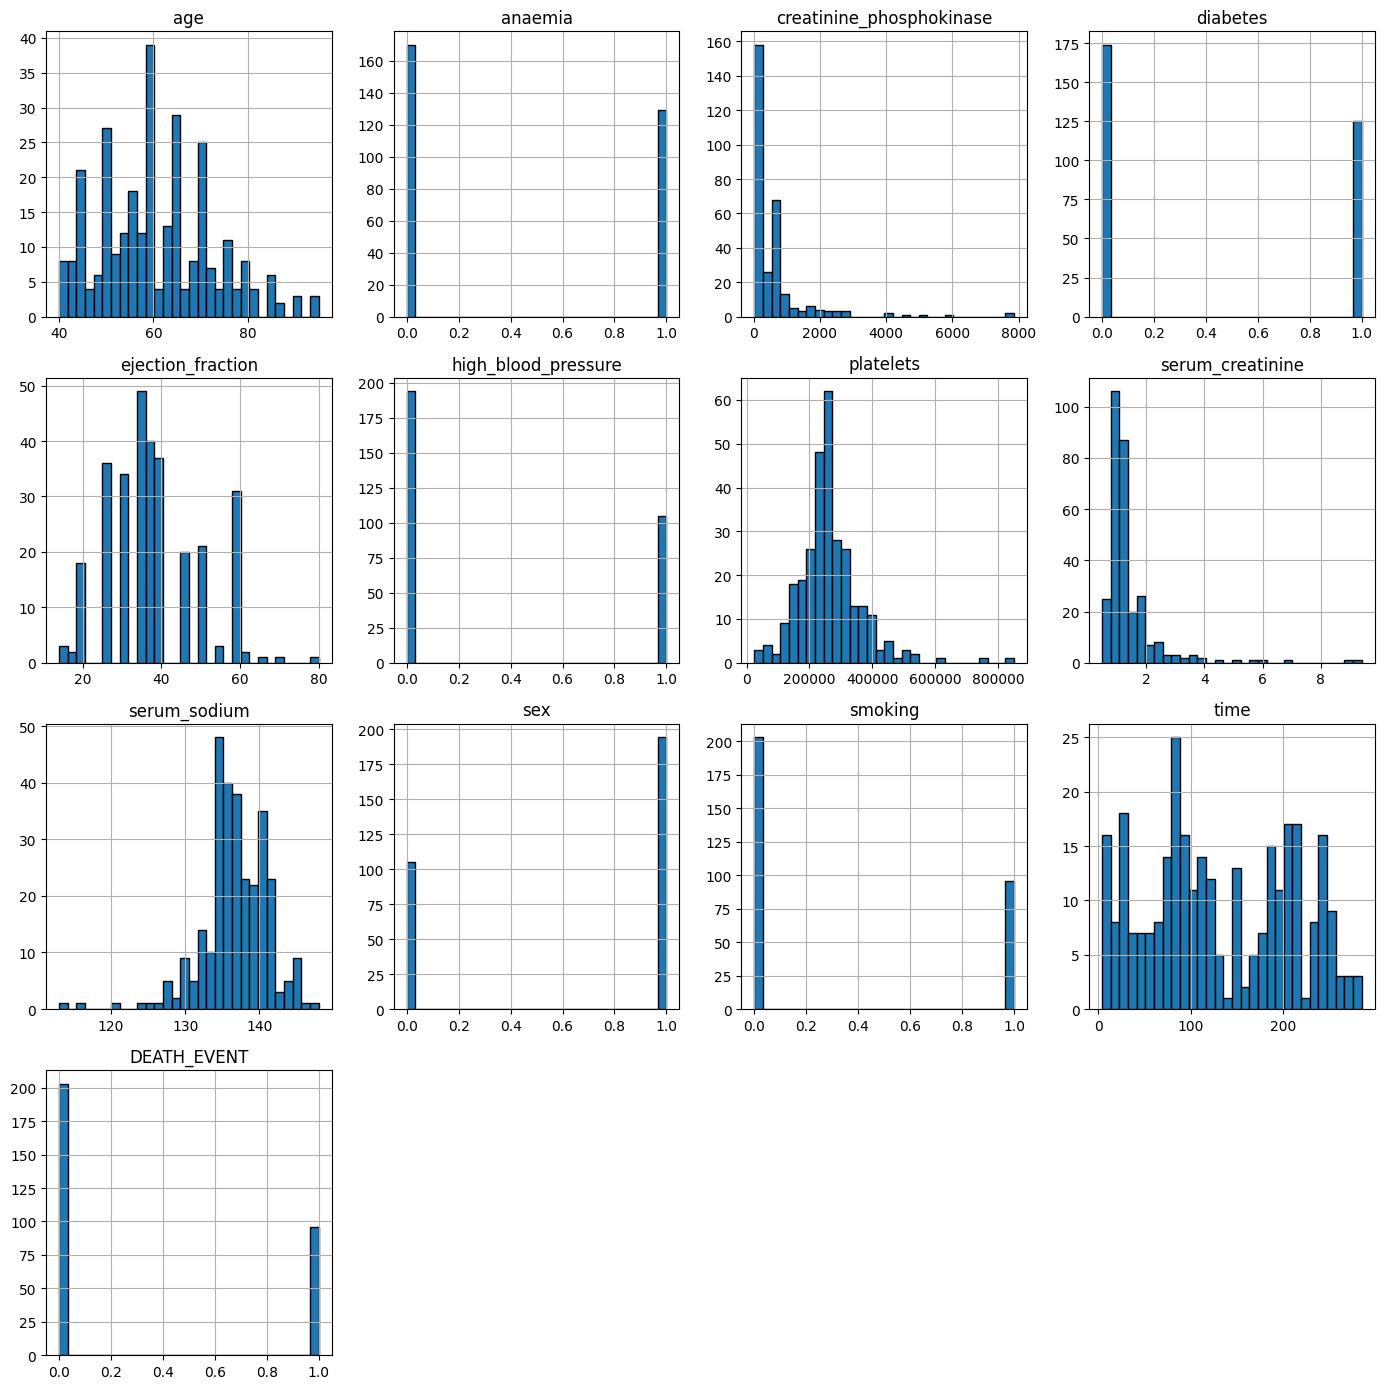

In [ ]:
# Tracer des histogrammes pour toutes les colonnes numériques

data.hist(bins=30, figsize=(14, 14), edgecolor='black')

# Afficher les graphiques
plt.tight_layout()
plt.show()

# **FEATURES IMPORTANCE**

# Matrice de corrélation

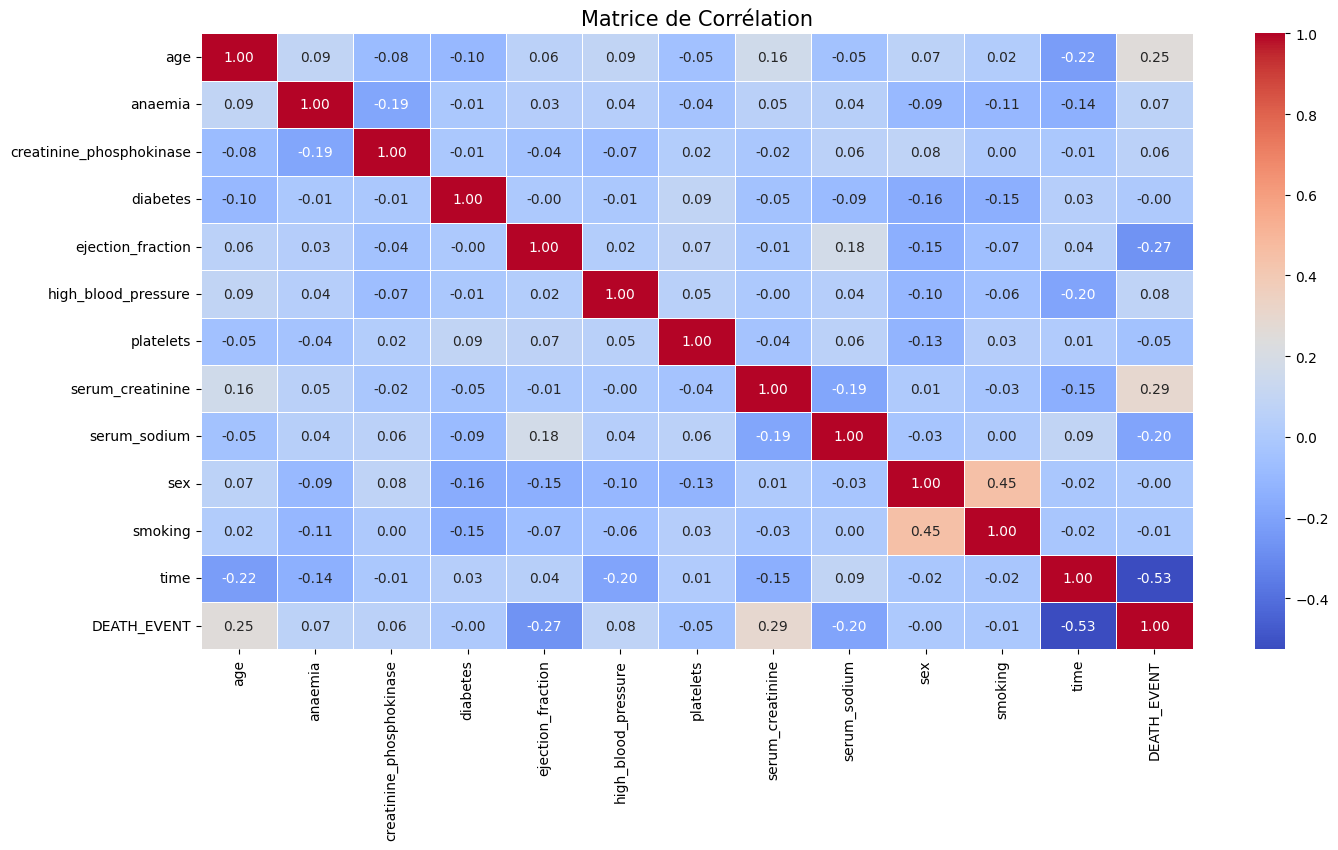

In [ ]:
# Calcul de la matrice de corrélation
corr = data.corr()

# Tracer la heatmap avec les annotations des valeurs de corrélation
plt.figure(figsize=(16, 8))  # Ajuster la taille de la figure selon le nombre de colonnes
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)

# Ajouter un titre
plt.title('Matrice de Corrélation', fontsize=15)

# Afficher la heatmap
plt.show()

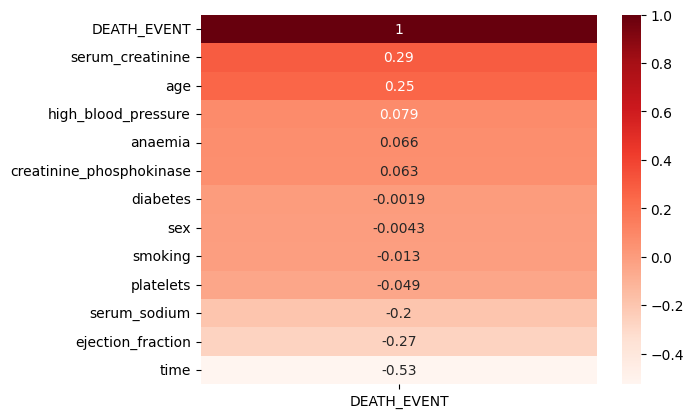

In [ ]:


heatmap = sns.heatmap(data.corr()[['DEATH_EVENT']].sort_values('DEATH_EVENT', ascending = False), annot = True, cmap = 'Reds')



# **Boxplots per Feature**

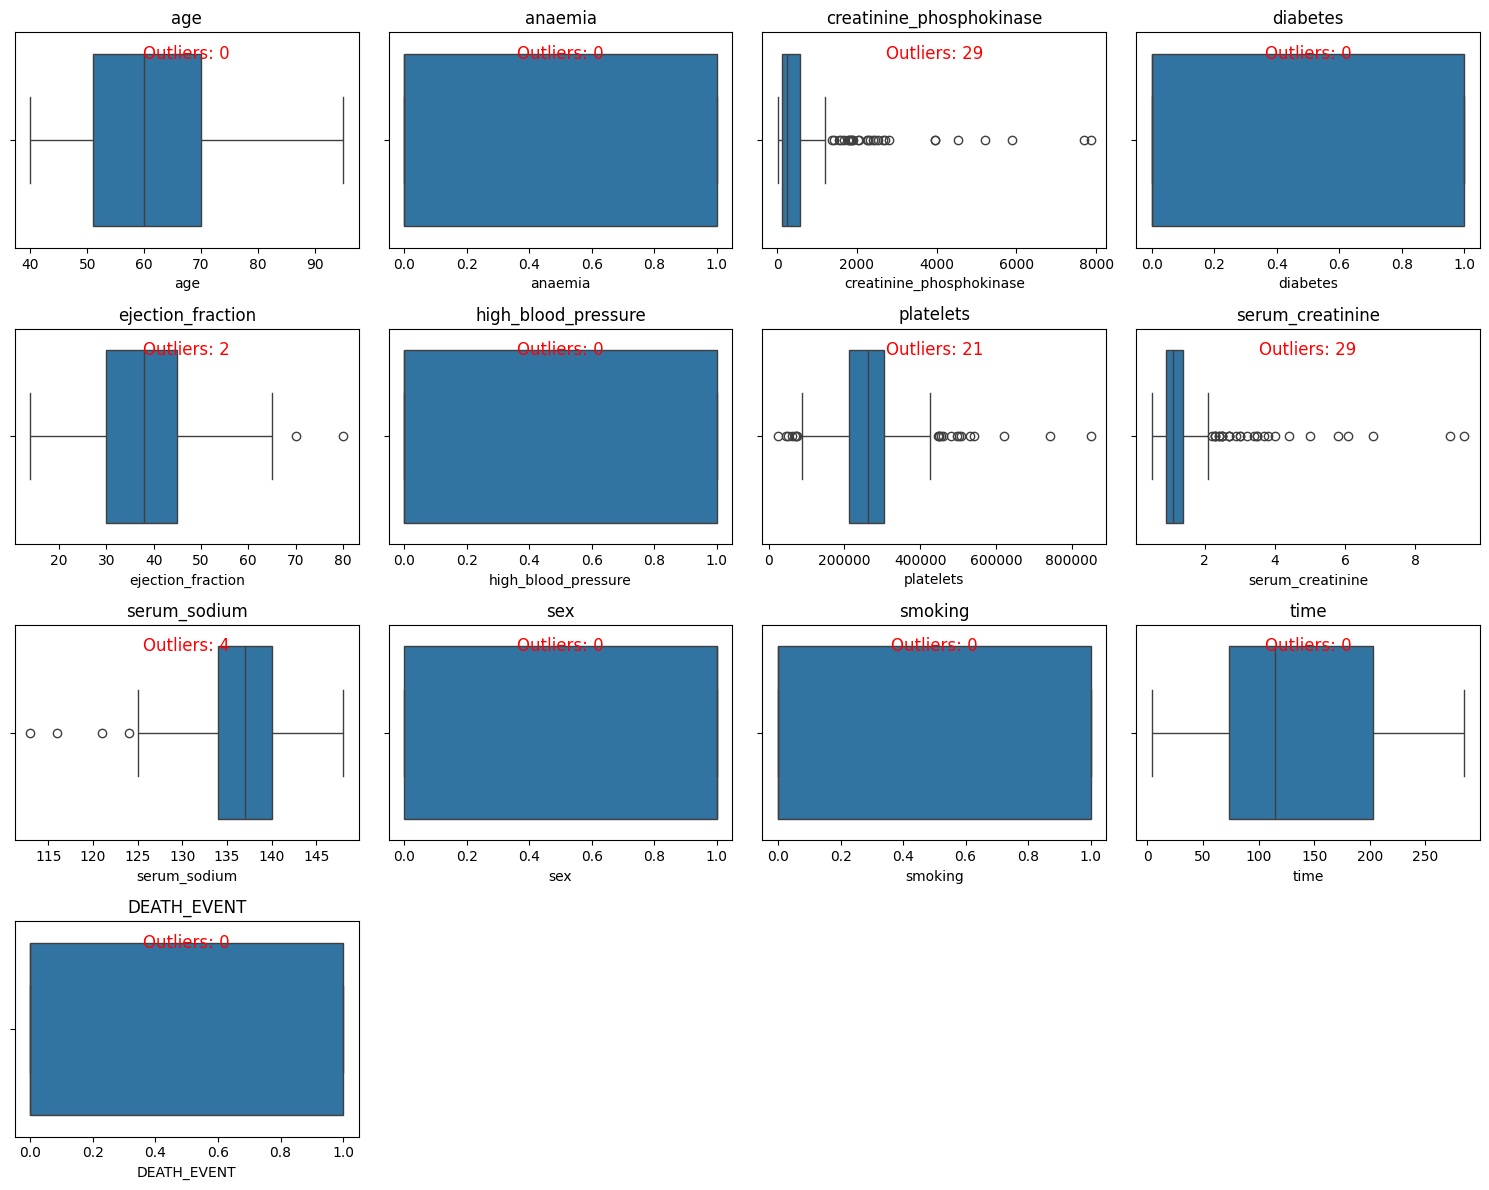

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Définir la taille de la figure
plt.figure(figsize=(15, 12))

# Calculer et afficher le nombre de valeurs aberrantes pour chaque variable
for i, col in enumerate(data.select_dtypes(include=['number']).columns):
    plt.subplot(4, 4, i + 1)  # Ajuste selon le nombre de colonnes
    sns.boxplot(x=data[col])
    plt.title(col)

    # Calcul des valeurs aberrantes
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Compter les valeurs aberrantes
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    # Afficher le nombre de valeurs aberrantes sur le graphique
    plt.text(0.5, 0.9, f'Outliers: {num_outliers}', ha='center', va='center', transform=plt.gca().transAxes, fontsize=12, color='red')

plt.tight_layout()
plt.show()


# **Preprocessing**

Prétraitement les valeurs aberrantes par la méthode de Médiane

In [ ]:
import pandas as pd

# Créer une copie de la base de données d'origine pour éviter de modifier l'original
datanew = data.copy()

# Parcourir chaque colonne numérique
for col in datanew.select_dtypes(include=['number']).columns:
    # Calcul des valeurs aberrantes
    Q1 = datanew[col].quantile(0.25)
    Q3 = datanew[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Calcul de la médiane de la colonne
    median = datanew[col].median()

    # Remplacer les valeurs aberrantes par la médiane
    datanew[col] = datanew[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

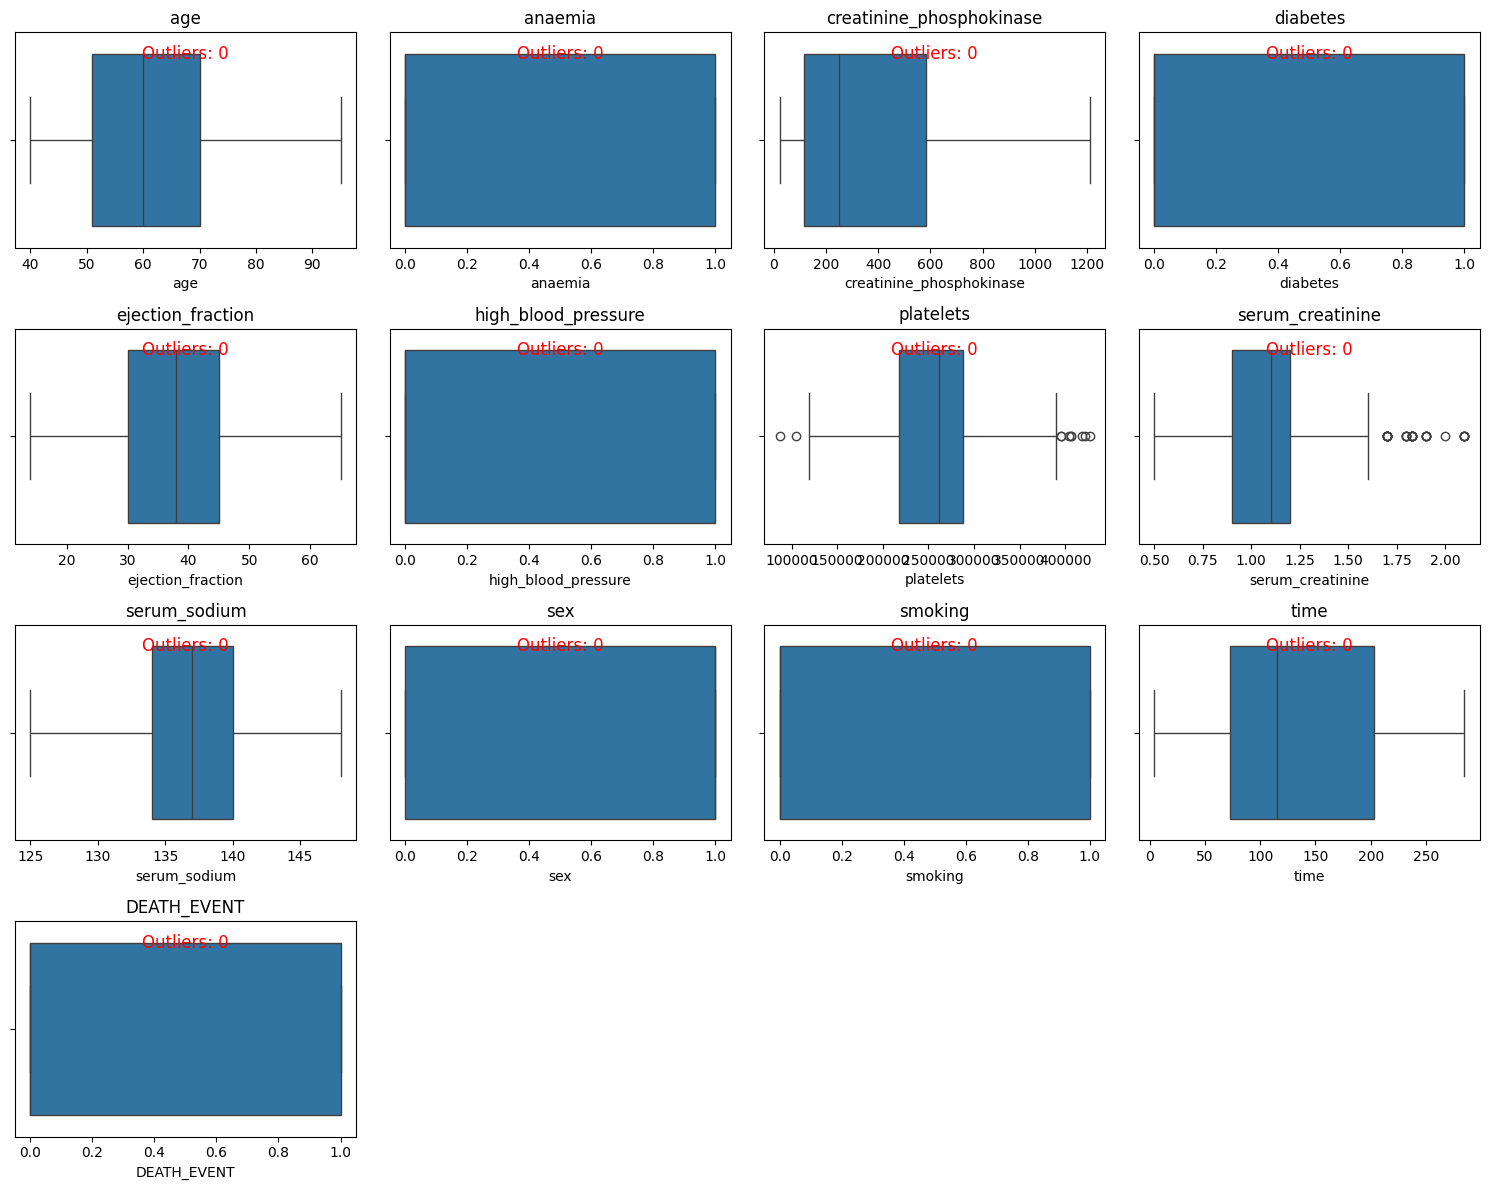

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Définir la taille de la figure
plt.figure(figsize=(15, 12))

# Calculer et afficher le nombre de valeurs aberrantes pour chaque variable
for i, col in enumerate(datanew.select_dtypes(include=['number']).columns):
    plt.subplot(4, 4, i + 1)  # Ajuste selon le nombre de colonnes
    sns.boxplot(x=datanew[col])
    plt.title(col)

    # Calcul des valeurs aberrantes
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Compter les valeurs aberrantes
    outliers = datanew[(datanew[col] < lower_bound) | (datanew[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    # Afficher le nombre de valeurs aberrantes sur le graphique
    plt.text(0.5, 0.9, f'Outliers: {num_outliers}', ha='center', va='center', transform=plt.gca().transAxes, fontsize=12, color='red')

plt.tight_layout()
plt.show()

# **Data balancing**

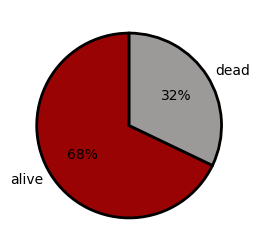

In [ ]:
plt.figure(figsize=(3, 3))
plt.pie(data["DEATH_EVENT"].value_counts(),
        labels = ["alive", "dead"],
        colors = ["#990303", "#9C9999"],
        wedgeprops={'edgecolor':'black', 'linewidth': 2},
        autopct = lambda y: str(round(y))+"%",
        startangle=90);



Nombre de 0 (survie) : 203
Nombre de 1 (décès) : 96


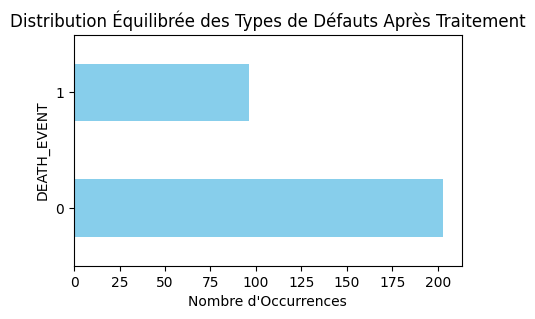

In [ ]:
import matplotlib.pyplot as plt

# Extraire la colonne "DEATH_EVENT"
y = datanew["DEATH_EVENT"]

# Compter le nombre de 0 et 1
death_event_counts = y.value_counts()

# Afficher les résultats
print(f"Nombre de 0 (survie) : {death_event_counts[0]}")
print(f"Nombre de 1 (décès) : {death_event_counts[1]}")

# Tracer la distribution
plt.figure(figsize=(5, 3))
y.value_counts().plot(kind='barh', color='skyblue')
plt.title("Distribution Équilibrée des Types de Défauts Après Traitement")
plt.xlabel("Nombre d'Occurrences")
plt.ylabel("DEATH_EVENT")
plt.show()


**Resampling par la méthode oversampling avec SMOTE pour atteindre 203 pour chaque classe dans le target**

Nombre de 0 (survie) après rééchantillonnage : 203
Nombre de 1 (décès) après rééchantillonnage : 203


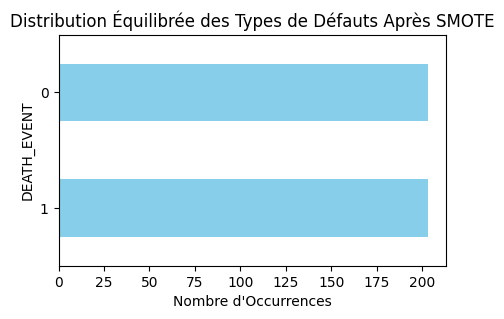

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# Séparer les variables indépendantes (features) et la variable cible (DEATH_EVENT)
X = datanew.drop(columns=["DEATH_EVENT"])
y = datanew["DEATH_EVENT"]

# Appliquer SMOTE pour réaliser un oversampling et équilibrer les classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Afficher la nouvelle distribution des classes après l'oversampling
print(f"Nombre de 0 (survie) après rééchantillonnage : {y_resampled.value_counts()[0]}")
print(f"Nombre de 1 (décès) après rééchantillonnage : {y_resampled.value_counts()[1]}")

# Créer un DataFrame avec les données rééchantillonnées
datanew_balanced = pd.DataFrame(X_resampled, columns=X.columns)
datanew_balanced["DEATH_EVENT"] = y_resampled

# Vérifier la distribution des données équilibrées
plt.figure(figsize=(5, 3))
datanew_balanced["DEATH_EVENT"].value_counts().plot(kind='barh', color='skyblue')
plt.title("Distribution Équilibrée des Types de Défauts Après SMOTE")
plt.xlabel("Nombre d'Occurrences")
plt.ylabel("DEATH_EVENT")
plt.show()


# **Séparation des features et de la target pour la suite du traitement**

In [ ]:
X = datanew_balanced.drop('DEATH_EVENT', axis=1)
y_final = datanew_balanced['DEATH_EVENT']

# **Normalisation des données**

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Initialiser le scaler
scaler = StandardScaler()

# Appliquer le scaling sur les données équilibrées
data_scaled = scaler.fit_transform(X)

# Convertir le tableau NumPy en DataFrame
X_final = pd.DataFrame(data_scaled, columns=X.columns)

# Afficher les premières lignes du DataFrame mis à l'échelle
X_final.head(80)
X_final.shape

(406, 12)

In [ ]:
import pickle #pour la sauvegarde des models

# **SPLITTING FOR DATA TRAINING**

In [ ]:
# Séparation des données (validation simple). On peut demander la validation croisée)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X_final, y_final, test_size=0.2, stratify= y_final, random_state=2)
Y_train.shape

(324,)

#**Classification models & MODEL TRAINING**

All models are evaluated considering the following metrics:

- **Accuracy**:
  $$
  \text{accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
  $$

- **Precision**:
  $$
  \text{precision} = \frac{TP}{TP + FP}
  $$

- **Recall**:
  $$
  \text{recall} = \frac{TP}{TP + FN}
  $$

- **F1 Score**:
  $$
  F_1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}
  $$

Moreover, **ROC curve** is also evaluated.


#**XGBoost Classifier**

**el houssine kamili**


Model saved successfully
XGBoost Classifier:
Accuracy: 0.9146
Precision: 0.9474
Recall: 0.8780
F1-Score: 0.9114
ROC-AUC: 0.9506


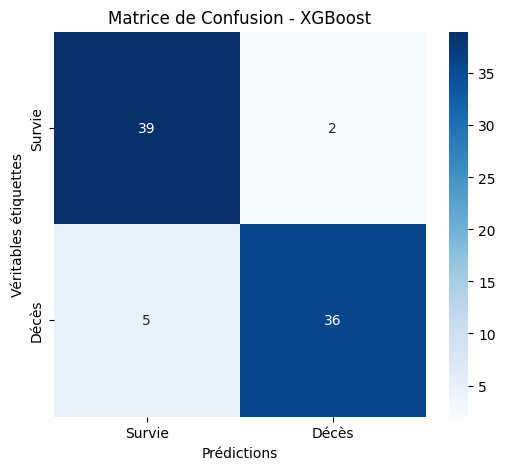

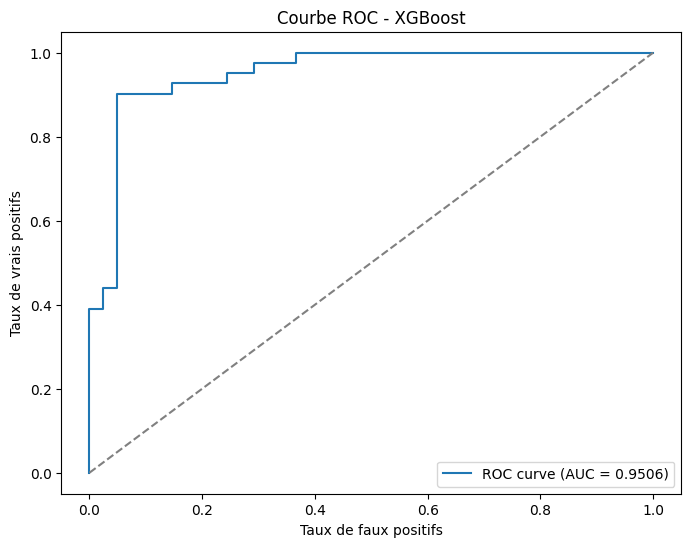

In [ ]:
# XGBoost Classifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Entraînement du modèle
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, Y_train)

#save model
with open("xgb_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)
    print("Model saved successfully")

# Prédictions
Y_pred_xgb = xgb_model.predict(X_test)
Y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Évaluation des métriques
accuracy_xgb = accuracy_score(Y_test, Y_pred_xgb)
precision_xgb = precision_score(Y_test, Y_pred_xgb)
recall_xgb = recall_score(Y_test, Y_pred_xgb)
f1_xgb = f1_score(Y_test, Y_pred_xgb)
roc_auc_xgb = roc_auc_score(Y_test, Y_prob_xgb)

# Affichage des résultats
print("XGBoost Classifier:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"ROC-AUC: {roc_auc_xgb:.4f}")

# Matrice de confusion
cm_xgb = confusion_matrix(Y_test, Y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - XGBoost")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
fpr_xgb, tpr_xgb, _ = roc_curve(Y_test, Y_prob_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"ROC curve (AUC = {roc_auc_xgb:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - XGBoost")
plt.legend(loc="lower right")
plt.show()

# **FEATURE IMPORTANCE**

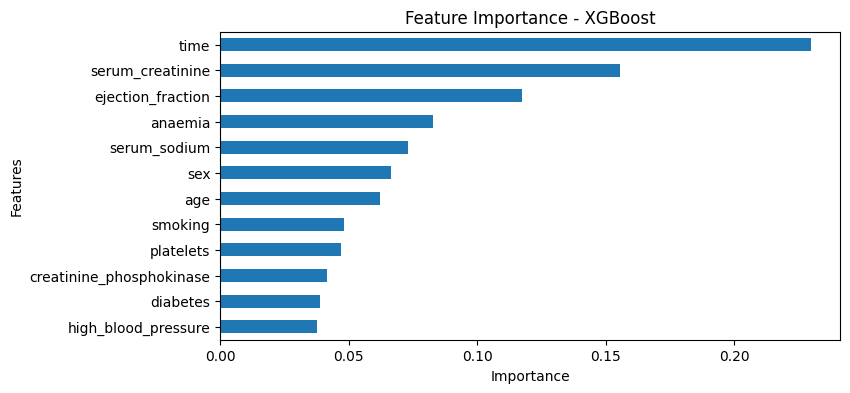

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Vérifier si le modèle est entraîné
if hasattr(xgb_model, "feature_importances_"):
    feature_importance_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
    feature_importance_xgb.sort_values(ascending=True).plot(kind='barh', figsize=(8, 4), title="Feature Importance - XGBoost")
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.show()
else:
    print("L'attribut feature_importances_ n'existe pas pour ce modèle.")


# **Logistic** Regression (selma)

Logistic Regression:
Accuracy: 0.7927
Precision: 0.8158
Recall: 0.7561
F1-Score: 0.7848
ROC-AUC: 0.8733


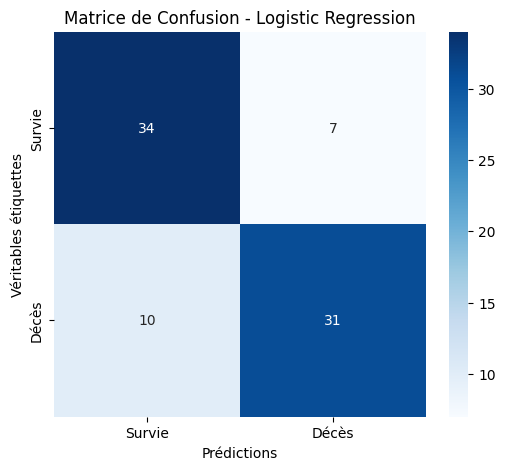

<function matplotlib.pyplot.ylabel(ylabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['bottom', 'center', 'top'] | None" = None, **kwargs) -> 'Text'>

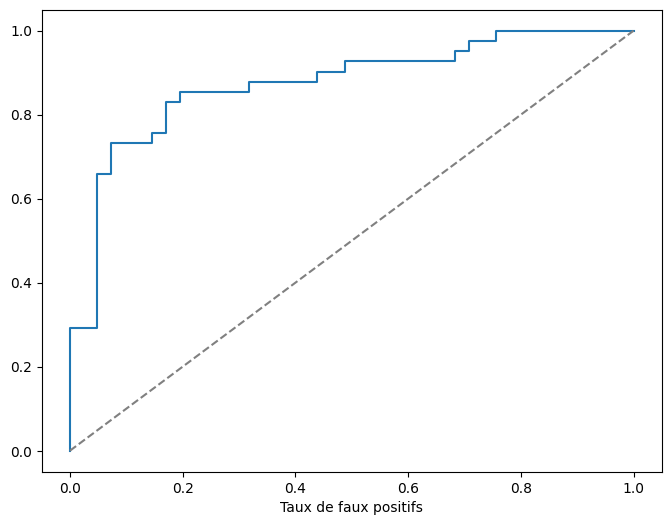

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Entraînement du modèle
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model.fit(X_train, Y_train)

# Prédictions
Y_pred_log_reg = log_reg_model.predict(X_test)
Y_prob_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Évaluation des métriques
accuracy_log_reg = accuracy_score(Y_test, Y_pred_log_reg)
precision_log_reg = precision_score(Y_test, Y_pred_log_reg)
recall_log_reg = recall_score(Y_test, Y_pred_log_reg)
f1_log_reg = f1_score(Y_test, Y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(Y_test, Y_prob_log_reg)

# Affichage des résultats
print("Logistic Regression:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print(f"ROC-AUC: {roc_auc_log_reg:.4f}")

# Matrice de confusion
cm_log_reg = confusion_matrix(Y_test, Y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - Logistic Regression")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
fpr_log_reg, tpr_log_reg, _ = roc_curve(Y_test, Y_prob_log_reg)
plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, label=f"ROC curve (AUC = {roc_auc_log_reg:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel

# LightGBM Classifier **chahida**

[LightGBM] [Info] Number of positive: 162, number of negative: 162
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 421
[LightGBM] [Info] Number of data points in the train set: 324, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

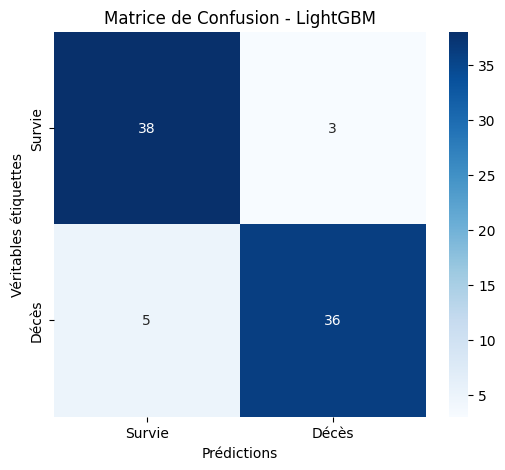

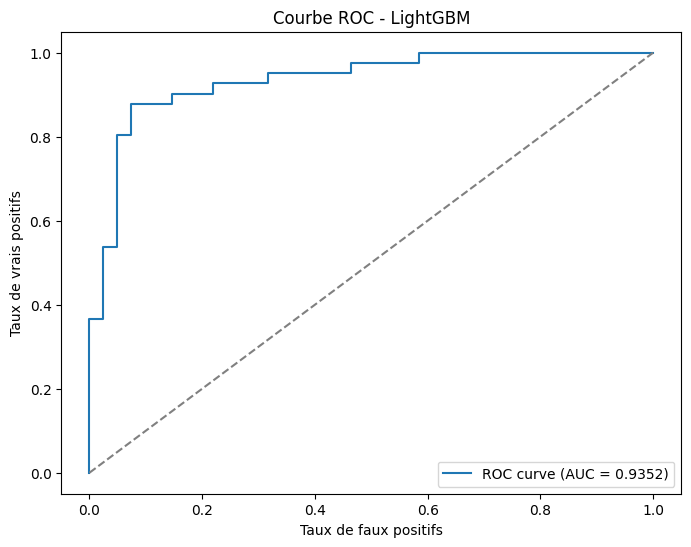

In [ ]:
# LightGBM Classifier
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve
)

# Entraînement du modèle
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, Y_train)  # Utilisation de Y_train

# Prédictions
Y_pred_lgb = lgb_model.predict(X_test)
Y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Évaluation des métriques
accuracy_lgb = accuracy_score(Y_test, Y_pred_lgb)
precision_lgb = precision_score(Y_test, Y_pred_lgb)
recall_lgb = recall_score(Y_test, Y_pred_lgb)
f1_lgb = f1_score(Y_test, Y_pred_lgb)
roc_auc_lgb = roc_auc_score(Y_test, Y_prob_lgb)

# Affichage des résultats
print("LightGBM Classifier:")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(f"F1-Score: {f1_lgb:.4f}")
print(f"ROC-AUC: {roc_auc_lgb:.4f}")

# Matrice de confusion
cm_lgb = confusion_matrix(Y_test, Y_pred_lgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - LightGBM")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
fpr_lgb, tpr_lgb, _ = roc_curve(Y_test, Y_prob_lgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, label=f"ROC curve (AUC = {roc_auc_lgb:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - LightGBM")
plt.legend(loc="lower right")
plt.show()




# FEATURE IMPORTANCE

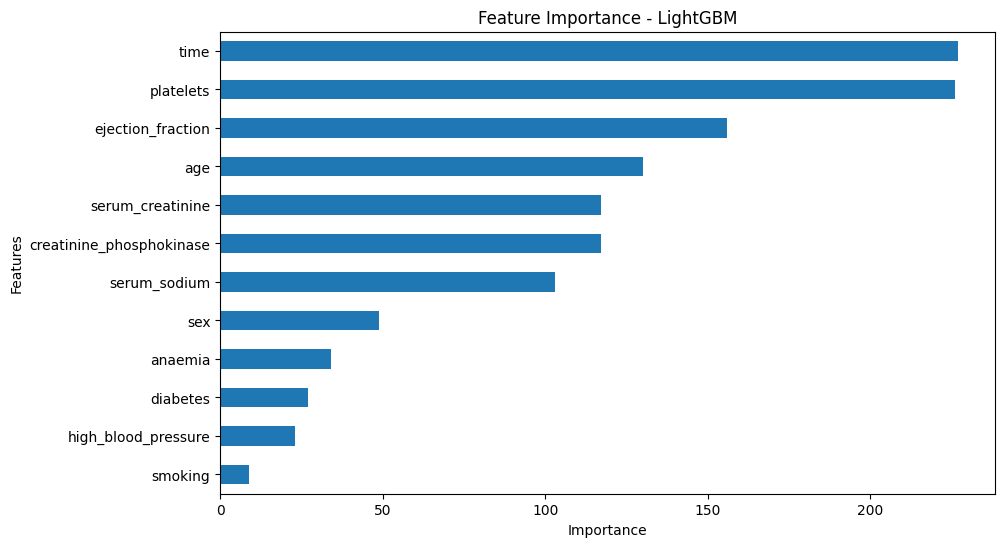

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Affichage des importances des caractéristiques triées
if hasattr(lgb_model, "feature_importances_"):
    feature_importance_lgb = pd.Series(lgb_model.feature_importances_, index=X_train.columns)
    feature_importance_lgb.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6), title="Feature Importance - LightGBM")
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.show()
else:
    print("L'attribut feature_importances_ n'existe pas pour ce modèle.")


## RANDOM FOREST DEFAULT PARAMETER.

✅ Random Forest Classifier:
🔹 Accuracy: 0.9024
🔹 Precision: 0.9231
🔹 Recall: 0.8780
🔹 F1-Score: 0.9000
🔹 ROC-AUC: 0.9340


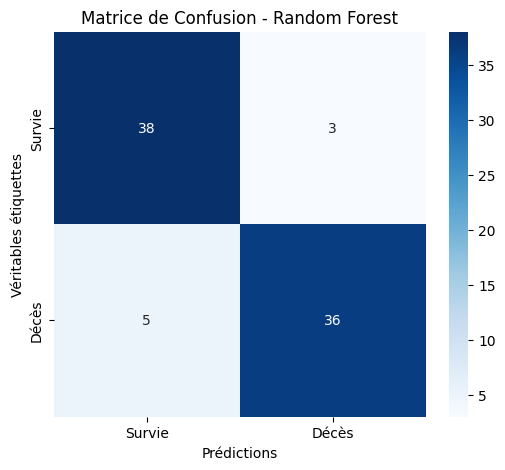

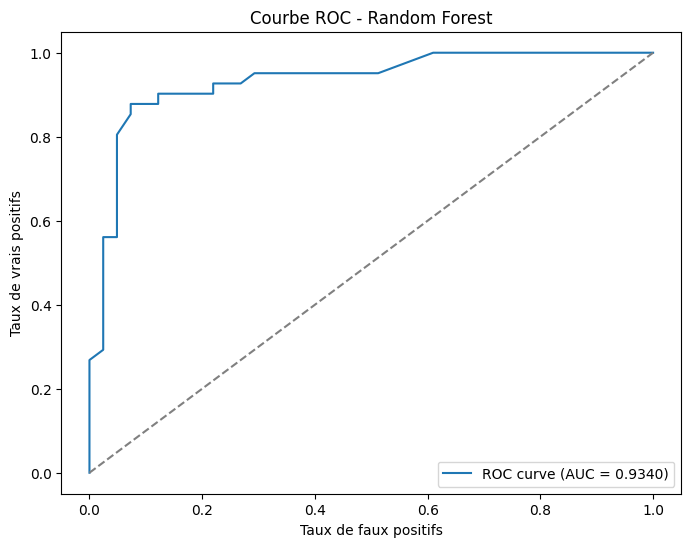

In [ ]:
# Importation des bibliothèques nécessaires
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve
)

# Entraînement du modèle
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, Y_train)

# Prédictions
Y_pred_rf = rf_model.predict(X_test)
Y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

with open("rf_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)  # ✅ Sauvegarde du bon modèle


# Évaluation des métriques
accuracy_rf = accuracy_score(Y_test, Y_pred_rf)
precision_rf = precision_score(Y_test, Y_pred_rf)
recall_rf = recall_score(Y_test, Y_pred_rf)
f1_rf = f1_score(Y_test, Y_pred_rf)
roc_auc_rf = roc_auc_score(Y_test, Y_prob_rf)

# Affichage des résultats
print("✅ Random Forest Classifier:")
print(f"🔹 Accuracy: {accuracy_rf:.4f}")
print(f"🔹 Precision: {precision_rf:.4f}")
print(f"🔹 Recall: {recall_rf:.4f}")
print(f"🔹 F1-Score: {f1_rf:.4f}")
print(f"🔹 ROC-AUC: {roc_auc_rf:.4f}")

# Matrice de confusion
cm_rf = confusion_matrix(Y_test, Y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - Random Forest")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
fpr_rf, tpr_rf, _ = roc_curve(Y_test, Y_prob_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"ROC curve (AUC = {roc_auc_rf:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Random Forest")
plt.legend(loc="lower right")
plt.show()





### **FEATURES IMPORTANCE**

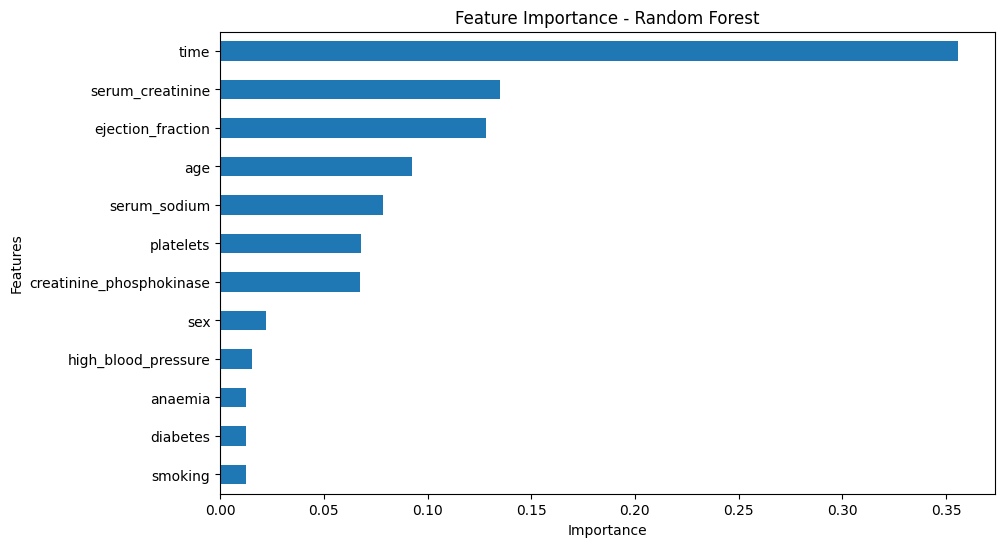

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Vérifier si le modèle est entraîné
if hasattr(rf_model, "feature_importances_"):
    feature_importance_rf = pd.Series(rf_model.feature_importances_, index=X_train.columns)
    feature_importance_rf.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6), title="Feature Importance - Random Forest")
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.show()
else:
    print("L'attribut feature_importances_ n'existe pas pour ce modèle.")


In [ ]:
!pip install ace-tools

##**DEEPENING ON ML WITH RANDOM FOREST**

###**Rééquilibrage des classes avec SMOTE**

In [ ]:
X = datanew.drop(columns=["DEATH_EVENT"])
y = datanew["DEATH_EVENT"]

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

datanew_balanced = pd.DataFrame(X_resampled, columns=X.columns)
datanew_balanced["DEATH_EVENT"] = y_resampled


###**Normalisation des données**

In [ ]:
scaler = StandardScaler()
X_final_smote = pd.DataFrame(scaler.fit_transform(datanew_balanced.drop(columns=["DEATH_EVENT"])), columns=X.columns)
y_final_smote = datanew_balanced["DEATH_EVENT"]

X_final_no_smote = pd.DataFrame(scaler.fit_transform(datanew.drop(columns=["DEATH_EVENT"])), columns=X.columns)
y_final_no_smote = datanew["DEATH_EVENT"]




# Initialisation des scalers
scaler_smote = StandardScaler()
scaler_no_smote = StandardScaler()

# Entraînement des scalers sur leurs jeux de données respectifs
scaler_smote.fit(datanew_balanced.drop(columns=["DEATH_EVENT"]))
scaler_no_smote.fit(datanew.drop(columns=["DEATH_EVENT"]))


# Sauvegarde des scalers
with open("scaler_smote.pkl", "wb") as file:
    pickle.dump(scaler_smote, file)

with open("scaler_no_smote.pkl", "wb") as file:
    pickle.dump(scaler_no_smote, file)

print("✅ Scalers sauvegardés avec succès scaler'")

✅ Scalers sauvegardés avec succès scaler'


###**Séparation des données**

In [ ]:

X_train_smote, X_test_smote, Y_train_smote, Y_test_smote = train_test_split(X_final_smote, y_final_smote, test_size=0.2, stratify=y_final_smote, random_state=2)
X_train_no_smote, X_test_no_smote, Y_train_no_smote, Y_test_no_smote = train_test_split(X_final_no_smote, y_final_no_smote, test_size=0.2, stratify=y_final_no_smote, random_state=2)

###**GridSearchCV**

In [ ]:
# --- Modélisation avec Optimisation (GridSearchCV) ---
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

###**Random Forest Classifier** Hyperparameters Optimized

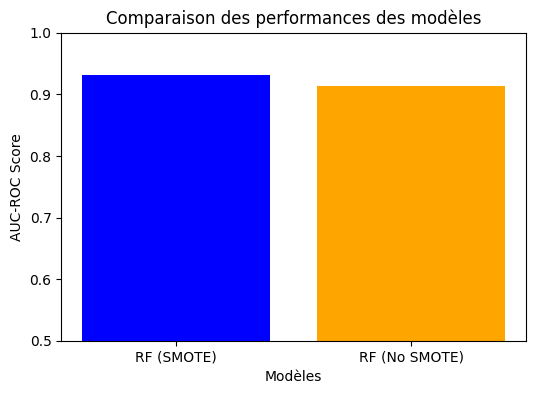

In [ ]:
rf = RandomForestClassifier(random_state=42)
grid_search_smote = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_smote.fit(X_train_smote, Y_train_smote)

grid_search_no_smote = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_no_smote.fit(X_train_no_smote, Y_train_no_smote)

# Récupération des meilleurs modèles
best_rf_smote = grid_search_smote.best_estimator_
best_rf_no_smote = grid_search_no_smote.best_estimator_

# Prédictions
roc_auc_rf_smote = roc_auc_score(Y_test_smote, best_rf_smote.predict_proba(X_test_smote)[:, 1])
roc_auc_rf_no_smote = roc_auc_score(Y_test_no_smote, best_rf_no_smote.predict_proba(X_test_no_smote)[:, 1])

# --- Visualisation des performances ---
plt.figure(figsize=(6, 4))
models = ['RF (SMOTE)', 'RF (No SMOTE)']
auc_scores = [roc_auc_rf_smote, roc_auc_rf_no_smote]
plt.bar(models, auc_scores, color=['blue', 'orange'])
plt.xlabel("Modèles")
plt.ylabel("AUC-ROC Score")
plt.title("Comparaison des performances des modèles")
plt.ylim(0.5, 1)
plt.show()



###EXEMPLE DE PREDICTION

Prediction: Survival, Probability: 0.32


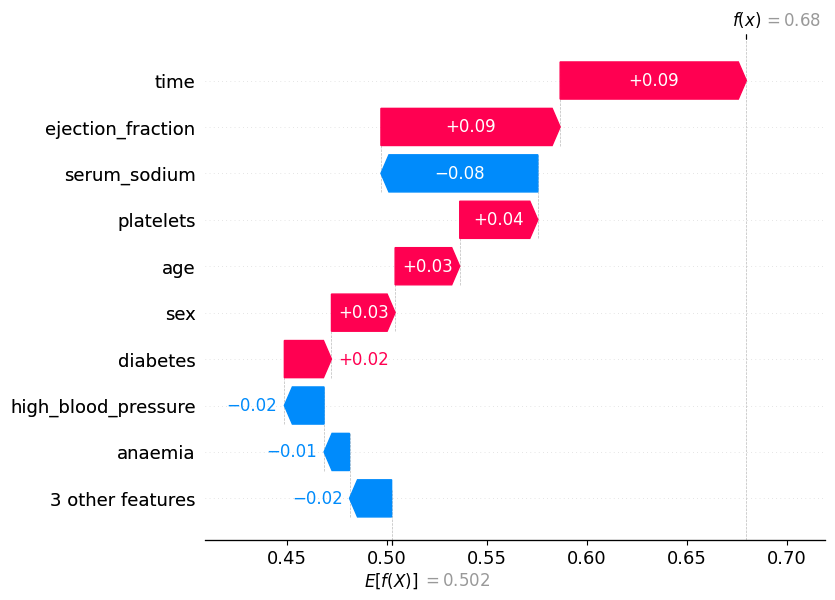

In [ ]:
# --- Chargement du modèle optimisé ---
with open("rf_model_smote.pkl", "rb") as file:
    best_rf_smote = pickle.load(file)


# --- Input utilisateur ---
def predict_heart_failure(input_data):
    input_df = pd.DataFrame([input_data], columns=X.columns)
    input_scaled = scaler.transform(input_df)
    input_scaled_df = pd.DataFrame(input_scaled, columns=X.columns)  # Correction ici
    prediction = best_rf_smote.predict(input_scaled_df)[0]
    probability = best_rf_smote.predict_proba(input_scaled_df)[0][1]
    return prediction, probability, input_scaled_df

# Exemple d'input utilisateur
user_input = {
    "age": 60,
    "anaemia": 0,
    "creatinine_phosphokinase": 582,
    "diabetes": 1,
    "ejection_fraction": 45,
    "high_blood_pressure": 0,
    "platelets": 265000,
    "serum_creatinine": 1.1,
    "serum_sodium": 135,
    "sex": 1,
    "smoking": 0,
    "time": 130
}

pred, prob, input_scaled_df = predict_heart_failure(user_input)
print(f"Prediction: {'Death' if pred == 1 else 'Survival'}, Probability: {prob:.2f}")

# --- Explication avec SHAP ---
# Upgrade shap to a version that includes the `check_additivity` argument
# or remove the argument if using an older version
# explainer = shap.TreeExplainer(best_rf_smote, X_train_smote, check_additivity=False)
explainer = shap.TreeExplainer(best_rf_smote, X_train_smote) # remove check_additivity
shap_values = explainer(input_scaled_df)

# Visualisation SHAP pour l'observation individuelle
# Access the SHAP values for the predicted class (pred)
shap.waterfall_plot(shap.Explanation(values=shap_values.values[0,:,pred], # Accessing SHAP values for the target class
                                     base_values=shap_values.base_values[0,pred], # Accessing base values for the target class
                                     feature_names=X.columns))

# 📌 *Comparaison des modèles*
Nous allons entraîner et comparer les modèles suivants :
- *Random Forest*
- *XGBoost*
- *LightGBM*
- *Logistic Regression*

Le tableau affichera plusieurs métriques : *Accuracy, Precision, Recall, F1-score et ROC-AUC*.


In [ ]:
# accuracy_xgb, precision_xgb, recall_xgb, f1_xgb, roc_auc_xgb
# accuracy_log_reg, precision_log_reg, recall_log_reg, f1_log_reg, roc_auc_log_reg
# accuracy_lgb, precision_lgb, recall_lgb, f1_lgb, roc_auc_lgb
# accuracy_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf

# Crée un dictionnaire pour chaque modèle
metrics_dict = {
    "Random Forest": {
        "Accuracy": accuracy_rf,
        "Precision": precision_rf,
        "Recall": recall_rf,
        "F1-Score": f1_rf,
        "ROC-AUC": roc_auc_rf
    },
    "XGBoost": {
        "Accuracy": accuracy_xgb,
        "Precision": precision_xgb,
        "Recall": recall_xgb,
        "F1-Score": f1_xgb,
        "ROC-AUC": roc_auc_xgb
    },
    "Logistic Regression": {
        "Accuracy": accuracy_log_reg,
        "Precision": precision_log_reg,
        "Recall": recall_log_reg,
        "F1-Score": f1_log_reg,
        "ROC-AUC": roc_auc_log_reg
    },
    "LightGBM": {
        "Accuracy": accuracy_lgb,
        "Precision": precision_lgb,
        "Recall": recall_lgb,
        "F1-Score": f1_lgb,
        "ROC-AUC": roc_auc_lgb
    }
}

# Convertir en DataFrame
results_df = pd.DataFrame(metrics_dict).T  # .T pour avoir les modèles en lignes
results_df
display(results_df)



,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.902439,0.923077,0.878049,0.900000,0.933968
XGBoost,0.914634,0.947368,0.878049,0.911392,0.950625
Logistic Regression,0.792683,0.815789,0.756098,0.784810,0.873290
LightGBM,0.902439,0.923077,0.878049,0.900000,0.935158


<ipython-input-195-d4e1bf2faefb>:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=20, ha="right")  # Rotations du label
<ipython-input-195-d4e1bf2faefb>:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=20, ha="right")  # Rotations du label
<ipython-input-195-d4e1bf2faefb>:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=20, ha="right")  # Rotations du label
<ipython-input-195-d4e1bf2faefb>:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=20, ha="right")  # Rotations du label
<ipython-input-1

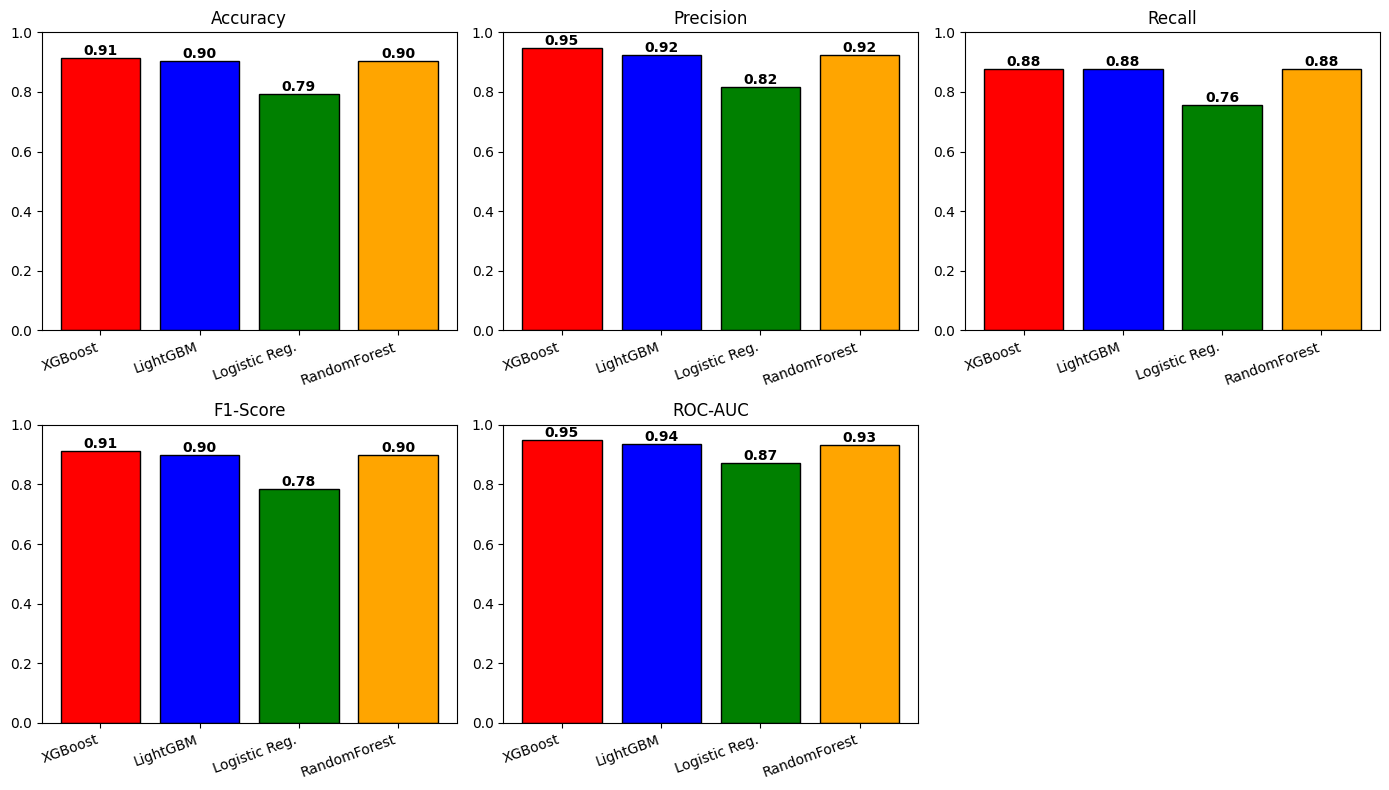

In [ ]:
color_map = {
    "XGBoost": "red",
    "LightGBM": "blue",
    "Logistic Reg.": "green",
    "RandomForest": "orange"
}
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# Création des sous-graphiques : 2 lignes, 3 colonnes
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
axes = axes.flatten()  # Pour itérer plus facilement

for i, metric in enumerate(metrics):
    ax = axes[i]

    # Récupère la colonne du metric
    values = results_df[metric]

    # Récupère les noms des modèles
    model_names = results_df.index

    # Pour la couleur de chaque barre, on utilise la map qu'on a définie :
    colors = [color_map[model] for model in model_names]

    # Création du bar chart
    ax.bar(model_names, values, color=colors, edgecolor='black')

    # Ajouter le titre, limites, et annotations
    ax.set_title(f"{metric}", fontsize=12)
    ax.set_ylim(0, 1)  # Car toutes les métriques sont normalisées entre 0 et 1
    ax.set_xticklabels(model_names, rotation=20, ha="right")  # Rotations du label

    # Ajouter la valeur au-dessus de chaque barre
    for j, v in enumerate(values):
        ax.text(j, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold', fontsize=10)

# Si tu veux masquer le dernier subplot vide (axes[5]) dans le cas où tu n'as que 5 métriques :
axes[-1].axis('off')  # supprime le 6e subplot (sinon laisse-le pour autre chose)

plt.tight_layout()
plt.show()


### 💾 **SAVE THE MODEL**
Sauvegarder le meilleur modèle au format *pickle* (.pkl) pour une réutilisation ultérieure.

---

In [ ]:
# --- Sauvegarde des modèles ---
with open("rf_model_smote.pkl", "wb") as file:
    pickle.dump(best_rf_smote, file)

with open("rf_model_no_smote.pkl", "wb") as file:
    pickle.dump(best_rf_no_smote, file)

print("Modèles optimisés sauvegardés avec succès !")

Modèles optimisés sauvegardés avec succès !
